# Crypto Statistical Arbitrage: Momentum, Reversal, and Carry

A short-horizon (4h) cross-sectional study across 35 large-cap crypto perpetual futures. Build clean price and funding panels, test momentum, reversal, and carry, and combine the survivors into a market-neutral book under train, validation, and holdout splits with realistic trading costs.

Design choices and rationale are in the README. The notebook is meant to be read top to bottom.

## Phase 0 - Data

Binance USDT-M perpetual 4h klines and funding rates, from the public data.binance.vision CDN, cached to `data/`. Perpetuals so that shorting and carry are coherent.

In [1]:
import io, os, zipfile, requests
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# 35 of the largest coins with Binance USDT-M perps (each enters when it lists)
UNIVERSE = ['BTC','ETH','XRP','ADA','LTC','LINK','XLM','BCH','ETC','TRX',
            'BNB','DOGE','ATOM','ALGO','SOL','DOT','AVAX','UNI','FIL','NEAR',
            'AAVE','MATIC','MKR','EOS','XTZ','THETA','COMP','ZEC','DASH','SAND',
            'GRT','CRV','SNX','AXS','ENJ']

START, END = '2020-01', '2026-04'

# time splits (chosen blind)
TRAIN   = ('2020-01-01', '2022-12-31')
VALID   = ('2023-01-01', '2023-12-31')
HOLDOUT = ('2024-01-01', None)

# transaction costs and slippage
MKT_BPS, LIMIT_BPS = 20, 7
ANN = np.sqrt(365 * 6)

DATA_DIR = 'data'

### Download helpers

Fetch and stitch each coin's 4h closes and funding across monthly files. Handles a header-row format change in 2024, rounds funding timestamps to the hour so they land on the grid, backfills any days missing from a short monthly file using the daily files, and continues 1:1 rebrands under their new ticker (MATIC to POL, EOS to A).

In [2]:
VISION = 'https://data.binance.vision/data/futures/um/monthly'
DAILY  = 'https://data.binance.vision/data/futures/um/daily'
KCOLS  = ['open_time','open','high','low','close','volume','close_time','quote_volume',
          'count','taker_buy_volume','taker_buy_quote_volume','ignore']
FCOLS  = ['calc_time','funding_interval_hours','last_funding_rate']
RENAMES = {'MATICUSDT': 'POLUSDT', 'EOSUSDT': 'AUSDT'}   # 1:1 rebrands; stitch successor onto the tail

def read_zip_csv(url, names):
    r = requests.get(url, timeout=30)
    if r.status_code == 404:                      # coin not listed that month/day
        return None
    r.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(r.content))
    df = pd.read_csv(z.open(z.namelist()[0]), header=None)
    if str(df.iloc[0, 0]) == names[0]:            # newer files have a header row
        df = df.iloc[1:]
    df.columns = names
    return df.astype(float)

def months(start, end):
    return [p.strftime('%Y-%m') for p in pd.period_range(start, end, freq='M')]

def get_series(sym, kind, mons):
    if kind == 'close':
        url = lambda m: f'{VISION}/klines/{sym}/4h/{sym}-4h-{m}.zip'
        cols, ts, val = KCOLS, 'open_time', 'close'
    else:
        url = lambda m: f'{VISION}/fundingRate/{sym}/{sym}-fundingRate-{m}.zip'
        cols, ts, val = FCOLS, 'calc_time', 'last_funding_rate'
    parts = [read_zip_csv(url(m), cols) for m in mons]
    parts = [p for p in parts if p is not None]
    if not parts:
        return None
    df = pd.concat(parts)
    idx = pd.to_datetime(df[ts], unit='ms')
    if kind == 'funding':                         # snap ms-jittered stamps onto the grid
        idx = idx.dt.round('h')
    s = pd.Series(df[val].values, index=idx)

    if kind == 'close':                           # monthly files are sometimes built short; backfill the
        grid = pd.date_range(s.index.min(), s.index.max(), freq='4h')   # missing days from the daily files
        for d in sorted({t.strftime('%Y-%m-%d') for t in grid.difference(s.index)}):
            day = read_zip_csv(f'{DAILY}/klines/{sym}/4h/{sym}-4h-{d}.zip', KCOLS)
            if day is not None:
                s = pd.concat([s, pd.Series(day['close'].values,
                                            index=pd.to_datetime(day['open_time'], unit='ms'))])
        s = s[~s.index.duplicated()].sort_index()

    if sym in RENAMES:                            # asset continued under a new ticker (1:1); stitch its tail on
        succ = get_series(RENAMES[sym], kind, mons)
        if succ is not None:
            s = pd.concat([s, succ[succ.index > s.index.max()]])
            s = s[~s.index.duplicated()].sort_index()
    return s

### Build the panels

`close` and `funding` as date-by-coin tables on a common 4h grid, cached to parquet.

In [3]:
def build_panels(coins, start, end):
    mons = months(start, end)
    close = {c: get_series(c + 'USDT', 'close',   mons) for c in coins}
    fund  = {c: get_series(c + 'USDT', 'funding', mons) for c in coins}
    close = pd.DataFrame({c: s for c, s in close.items() if s is not None}).sort_index()
    fund  = pd.DataFrame({c: s for c, s in fund.items()  if s is not None}).sort_index()
    close = close[~close.index.duplicated()]
    fund  = fund[~fund.index.duplicated()]
    grid  = pd.date_range(close.index.min(), close.index.max(), freq='4h')
    return close.reindex(grid), fund.reindex(grid)

px_path, f_path = f'{DATA_DIR}/close.parquet', f'{DATA_DIR}/funding.parquet'
if os.path.exists(px_path):
    close   = pd.read_parquet(px_path)
    funding = pd.read_parquet(f_path)
else:
    close, funding = build_panels(UNIVERSE, START, END)   # ~30 min on first run
    Path(DATA_DIR).mkdir(exist_ok=True)
    close.to_parquet(px_path)
    funding.to_parquet(f_path)

ret = close.pct_change()

### Data checks

Per-coin coverage, cumulative returns, and the funding distribution, to confirm the panels are clean before using them.

In [4]:
# per-coin coverage
cov = pd.DataFrame({
    'ret_samples':  ret.notna().sum(),
    'fund_samples': funding.notna().sum(),
    'first':        ret.apply(lambda s: s.first_valid_index()).dt.date,
    'last':         ret.apply(lambda s: s.last_valid_index()).dt.date,
})
# gaps = missing bars inside a coin's own listed life
cov['gaps'] = ret.apply(lambda s: s.loc[s.first_valid_index():s.last_valid_index()].isna().sum())

print('panel:', ret.shape, '|', ret.index.min().date(), 'to', ret.index.max().date())
print(cov.sort_values('first').to_string())

panel: (13872, 35) | 2020-01-01 to 2026-04-30
       ret_samples  fund_samples       first        last  gaps
BTC          13871          6936  2020-01-01  2026-04-30     0
ETH          13871          6936  2020-01-01  2026-04-30     0
BCH          13871          6936  2020-01-01  2026-04-30     0
XRP          13839          6920  2020-01-06  2026-04-30     0
EOS          13785          7908  2020-01-08  2026-04-30    42
LTC          13821          6911  2020-01-09  2026-04-30     0
TRX          13785          6893  2020-01-15  2026-04-30     0
ETC          13779          6890  2020-01-16  2026-04-30     0
LINK         13773          6887  2020-01-17  2026-04-30     0
XLM          13755          6880  2020-01-20  2026-04-30     0
ADA          13689          6880  2020-01-31  2026-04-30     0
DASH         13665          6833  2020-02-04  2026-04-30     0
ZEC          13659          6833  2020-02-05  2026-04-30     0
XTZ          13653          7687  2020-02-06  2026-04-30     0
ATOM     

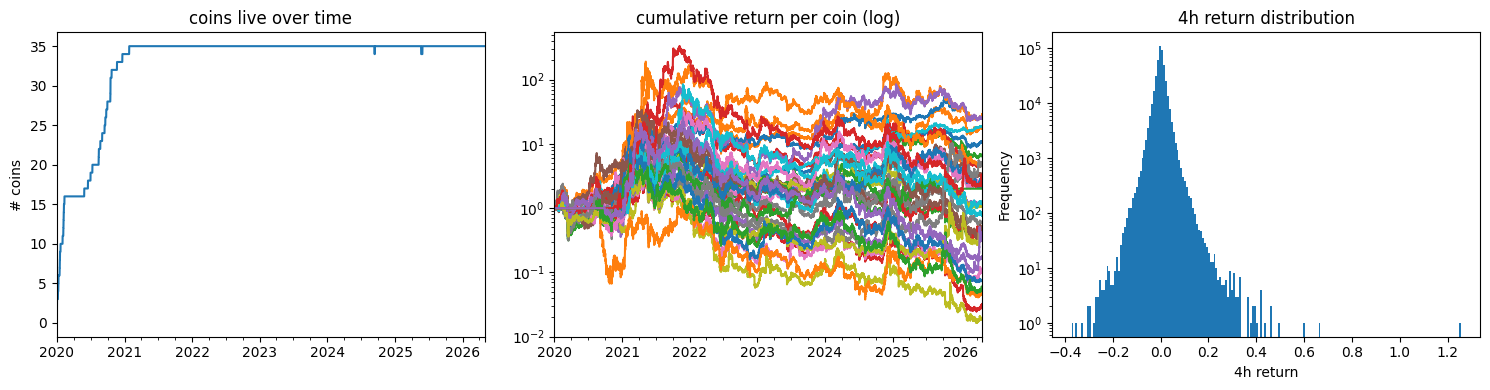

In [5]:
# visual sanity: coverage through time
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ret.notna().sum(axis=1).plot(ax=ax[0], title='coins live over time')
ax[0].set_ylabel('# coins')
(1 + ret.fillna(0)).cumprod().plot(ax=ax[1], logy=True, legend=False,
                                   title='cumulative return per coin (log)')
ret.stack().plot(kind='hist', bins=200, ax=ax[2], title='4h return distribution')
ax[2].set_yscale('log'); ax[2].set_xlabel('4h return')
plt.tight_layout(); plt.show()

Coverage is complete except for two brief, real trading halts during the 1:1 rebrand migrations (MATIC to POL in Sept 2024, EOS to A in May 2025), which show as small dips and which we stitch across so the assets stay in the panel. Short monthly files are otherwise backfilled from the daily archive, so every coin is continuous over its life.

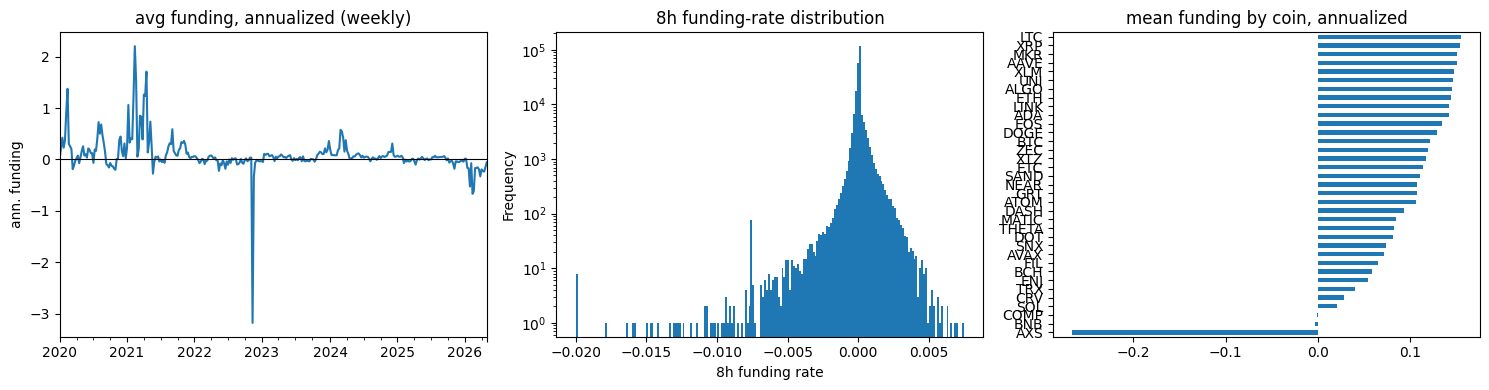

In [6]:
# funding sanity
PER_YR = 3 * 365
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
(funding.mean(axis=1).resample('W').mean() * PER_YR).plot(ax=ax[0],
                                          title='avg funding, annualized (weekly)')
ax[0].axhline(0, color='k', lw=.8); ax[0].set_ylabel('ann. funding')
funding.stack().plot(kind='hist', bins=200, ax=ax[1], title='8h funding-rate distribution')
ax[1].set_yscale('log'); ax[1].set_xlabel('8h funding rate')
(funding.mean() * PER_YR).sort_values().plot(kind='barh', ax=ax[2],
                                          title='mean funding by coin, annualized')
plt.tight_layout(); plt.show()

The late-2022 funding spike is the FTX collapse, almost entirely SOL. It is real data, but it is why the carry signal caps funding later.

AXS is the only coin with persistently negative funding because, as the collapsed leader of the 2021 GameFi bubble (Axie Infinity), its perpetual has traded below spot since the 2022 crash, meaning shorts pay longs far more often than not.

## Phase 1 - Signal zoo

Turn simple signals into portfolio weights and test them: cross-sectional (XS) and time-series (TS) momentum at several lookbacks, plus carry (short high funding). Gross Sharpe shows whether a signal predicts; net Sharpe shows what survives 20 bps. Train years only.

In [7]:
# portfolio construction
def norm(w):                       # scale to gross exposure = 1 each bar
    return w.div(w.abs().sum(axis=1), axis=0)

def xs_port(sig):                  # cross-sectional, dollar-neutral: rank -> demean -> normalize
    r = sig.rank(axis=1)
    r = r.sub(r.mean(axis=1), axis=0)
    return norm(r)

def ts_port(sig):                  # per-coin timing, tanh-squashed
    return norm(np.tanh(sig))

# --- returns, costs, performance ---
def gross(w):                      # price-only return stream (lagged to avoid lookahead)
    return (w.shift() * ret).sum(axis=1)

def turnover(w):
    return w.diff().abs().sum(axis=1)

def net(w, bps=MKT_BPS):           # subtract trading cost charged on turnover
    return gross(w) - turnover(w).shift() * (bps / 1e4)

def SR(r, window=TRAIN):           # annualized Sharpe over a date window
    r = r.loc[window[0]:window[1]].dropna()
    return r.mean() / r.std() * ANN

# --- signals ---
vol = ret.rolling(180, min_periods=30).std()       # ~30-day vol, normalizes TS signals
def past(h):
    return ret.rolling(h, min_periods=1).mean()     # average return over last h bars

def carry_port(k):                 # short high funding, smoothed over ~k funding periods
    return xs_port((-funding.ffill()).rolling(2 * k, min_periods=1).mean())

def carry_ret(k, bps=MKT_BPS):     # carry P&L includes funding cashflow
    w = carry_port(k)
    funding_pnl = -(w.shift() * funding.fillna(0)).sum(axis=1)   # longs pay positive funding
    return gross(w) + funding_pnl - turnover(w).shift() * (bps / 1e4)

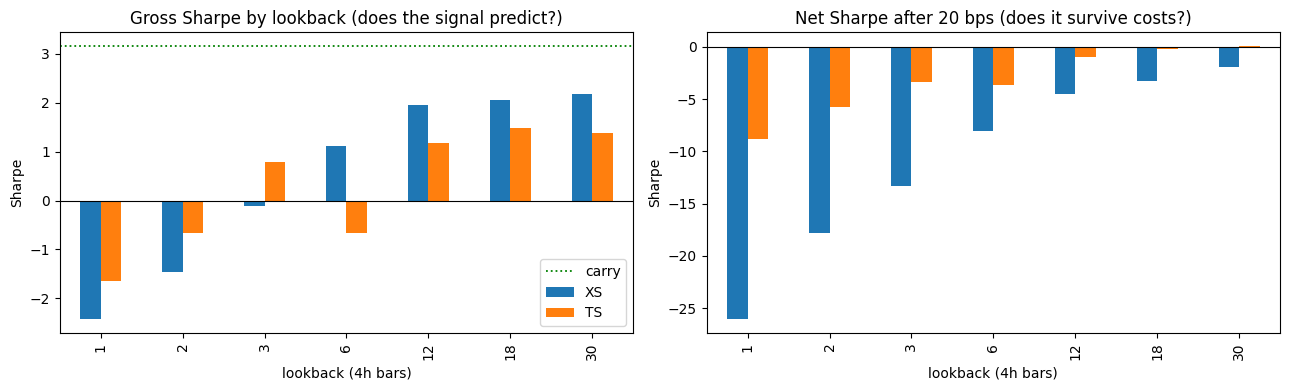

In [8]:
# momentum/reversal across horizons: gross = does it predict, net = what survives 20 bps
HORIZONS = [1, 2, 3, 6, 12, 18, 30]              # 4h bars: 4h ... 5 days
xs = lambda h: xs_port(past(h))
ts = lambda h: ts_port(np.sqrt(h) * past(h) / vol)
by_h = lambda fn, pnl: [SR(pnl(fn(h))) for h in HORIZONS]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
pd.DataFrame({'XS': by_h(xs, gross), 'TS': by_h(ts, gross)}, index=HORIZONS).plot(kind='bar', ax=ax[0])
ax[0].axhline(SR(carry_ret(3, 0)), color='green', ls=':', lw=1.3, label='carry')   # carry gross, for reference
ax[0].set_title('Gross Sharpe by lookback (does the signal predict?)'); ax[0].legend()
pd.DataFrame({'XS': by_h(xs, net), 'TS': by_h(ts, net)}, index=HORIZONS).plot(kind='bar', ax=ax[1], legend=False)
ax[1].set_title('Net Sharpe after 20 bps (does it survive costs?)')
for a in ax:
    a.axhline(0, color='k', lw=.8); a.set_xlabel('lookback (4h bars)'); a.set_ylabel('Sharpe')
plt.tight_layout(); plt.show()

Short lookbacks reverse, longer lookbacks trend, and carry is strong. But net of 20 bps every signal is deeply negative: they trade the whole book each bar. Phase 2 attacks the cost.

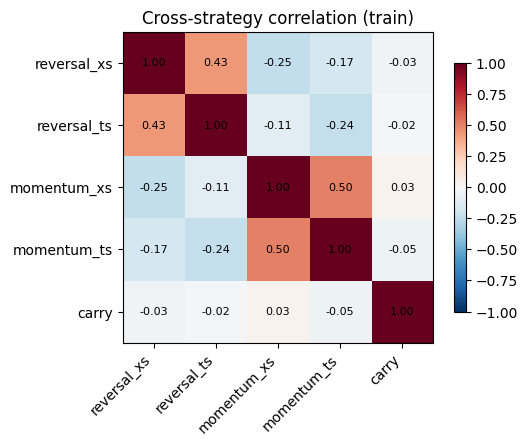

In [9]:
# the surviving bets, oriented to a positive gross Sharpe, and how (un)correlated they are
bets = pd.DataFrame({
    'reversal_xs': -gross(xs_port(past(1))),
    'reversal_ts': -gross(ts_port(past(1) / vol)),
    'momentum_xs':  gross(xs_port(past(30))),
    'momentum_ts':  gross(ts_port(np.sqrt(30) * past(30) / vol)),
    'carry':        carry_ret(3, 0),
}).loc[TRAIN[0]:TRAIN[1]]
corr = bets.corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Cross-strategy correlation (train)')
fig.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()

Reversal, momentum, and carry are lowly correlated, so they can diversify each other later.

## Phase 2 - Beating costs

On train and validation only: is each signal stable across both periods, and does trading less (longer holds) let net Sharpe clear zero? Funding cashflows are capped to avoid one-off spikes.

In [10]:
# Phase 2 helpers
def hold(w, H):                    # trade less: average target weights over H bars
    return w.rolling(H, min_periods=1).mean()

FUND_CAP = 0.005                   # cap funding cashflow at +/-0.5% per 8h (FTX/SOL outlier)
def carry_pnl(w, bps=MKT_BPS):     # carry P&L = price + (capped) funding cashflow - cost
    funding_pnl = -(w.shift() * funding.clip(-FUND_CAP, FUND_CAP).fillna(0)).sum(axis=1)
    return gross(w) + funding_pnl - turnover(w).shift() * (bps / 1e4)

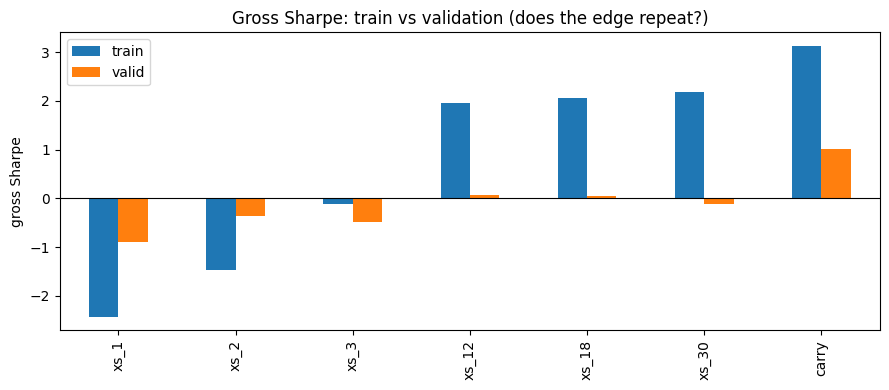

In [11]:
# stability: gross Sharpe in train vs validation (a real edge should hold in BOTH; holdout sealed)
rows = {f'xs_{h}': gross(xs_port(past(h))) for h in [1, 2, 3, 12, 18, 30]}
rows['carry'] = carry_pnl(carry_port(3), 0)
stab = pd.DataFrame({nm: {'train': SR(r, TRAIN), 'valid': SR(r, VALID)} for nm, r in rows.items()}).T

stab.plot(kind='bar', figsize=(9, 4), title='Gross Sharpe: train vs validation (does the edge repeat?)')
plt.axhline(0, color='k', lw=.8); plt.ylabel('gross Sharpe'); plt.xlabel('')
plt.tight_layout(); plt.show()

Carry is stable in both periods; momentum is strong on train but weak in 2023; reversal is real but trades too much to survive costs, so we drop it. Keep momentum and carry.

### The plan: slow the trading down

The only lever that cuts cost without touching the signal is turnover, so we hold positions longer (averaging the weights over H bars) and sweep H from 1 to 96 to watch turnover fall and net Sharpe climb.

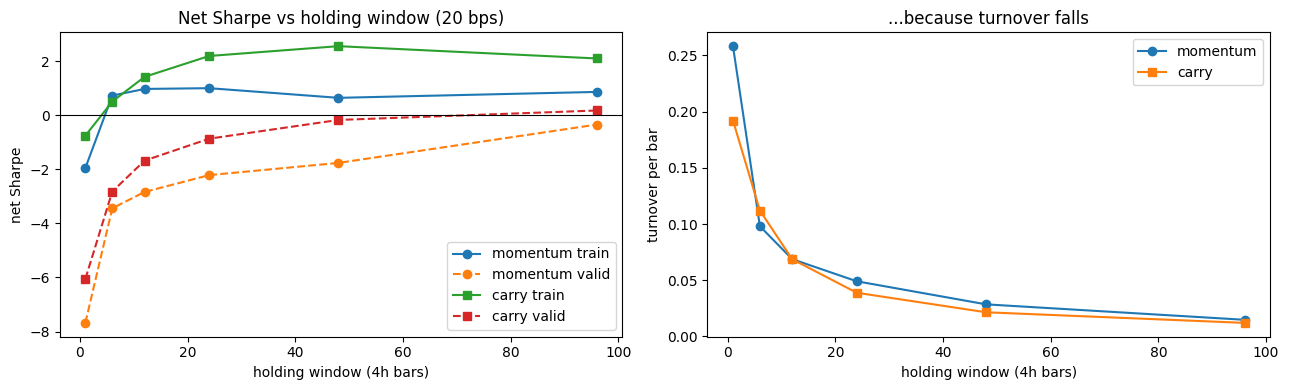

In [12]:
# net Sharpe rises as we hold longer, because turnover falls
HOLDS = [1, 6, 12, 24, 48, 96]
mom_b, car_b = lambda: xs_port(past(30)), lambda: carry_port(3)
def curve(build, pnl, win): return [SR(pnl(hold(build(), H), MKT_BPS), win) for H in HOLDS]
def turns(build):          return [turnover(hold(build(), H)).loc[TRAIN[0]:TRAIN[1]].mean() for H in HOLDS]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(HOLDS, curve(mom_b, net, TRAIN), '-o',  label='momentum train')
ax[0].plot(HOLDS, curve(mom_b, net, VALID), '--o', label='momentum valid')
ax[0].plot(HOLDS, curve(car_b, carry_pnl, TRAIN), '-s',  label='carry train')
ax[0].plot(HOLDS, curve(car_b, carry_pnl, VALID), '--s', label='carry valid')
ax[0].axhline(0, color='k', lw=.8); ax[0].set_title('Net Sharpe vs holding window (20 bps)')
ax[0].set_xlabel('holding window (4h bars)'); ax[0].set_ylabel('net Sharpe'); ax[0].legend()
ax[1].plot(HOLDS, turns(mom_b), '-o', label='momentum'); ax[1].plot(HOLDS, turns(car_b), '-s', label='carry')
ax[1].set_title('...because turnover falls'); ax[1].set_xlabel('holding window (4h bars)')
ax[1].set_ylabel('turnover per bar'); ax[1].legend()
plt.tight_layout(); plt.show()

Slower trading helps, but momentum stays marginal after costs. Rather than hand-tune them, Phase 3 adopts a published signal construction.

## Phase 3 - A published signal

The momentum sleeve uses the Baz / Rohrbach trend signal: the average of three Exponentially Weighted Moving Averages (EWMA) crossovers at different speeds, volatility-normalized, with a response that down-weights extreme trends. Parameters come from the literature, not fit to our data. We also try a crypto-faster variant since crypto trends quicker than FX. Sources in the README.

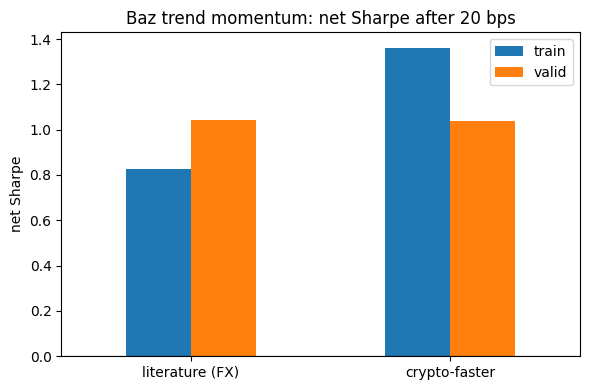

In [13]:
# Baz/Rohrbach (2017) trend signal: average of 3 EWMA crossovers, vol-normalized, bell response
DAY = 6     # 4h bars per day
def baz(px, pairs):                          # pairs = (short, long) EWMA half-lives in DAYS
    sig = 0
    for S, L in pairs:
        x = px.ewm(halflife=S*DAY, min_periods=DAY).mean() - px.ewm(halflife=L*DAY, min_periods=DAY).mean()
        y = x / px.rolling(63*DAY,  min_periods=30*DAY).std()    # / 3-month price vol
        z = y / y.rolling(252*DAY, min_periods=60*DAY).std()     # / 1-year signal vol
        sig = sig + z*np.exp(-z**2/4)/(np.sqrt(2)*np.exp(-0.5))  # bell: down-weights extreme trends
    return sig / len(pairs)

variants = {'literature (FX)': [(8,24),(16,48),(32,96)],         # Rohrbach et al. defaults (days)
            'crypto-faster':   [(4,12),(8,24),(16,48)]}          # halved: crypto trends quicker
res = pd.DataFrame({nm: {'train': SR(net(xs_port(baz(close, p))), TRAIN),
                         'valid': SR(net(xs_port(baz(close, p))), VALID)} for nm, p in variants.items()}).T
res.plot(kind='bar', figsize=(6, 4), rot=0, title='Baz trend momentum: net Sharpe after 20 bps')
plt.axhline(0, color='k', lw=.8); plt.ylabel('net Sharpe'); plt.tight_layout(); plt.show()

The trend signal is net-positive on train and the unseen 2023, with tiny turnover. Phase 4 re-picks its speed each quarter and blends it with carry.

## Phase 4 - Combine

Blend momentum and carry. To avoid fitting weights to the period we score, both the momentum speed and the blend weights are re-chosen each quarter from the prior year only and held forward. Weights are inverse-volatility.

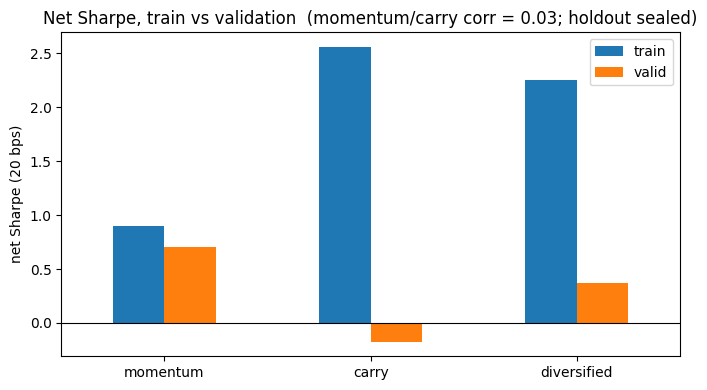

In [14]:
# momentum + carry, with the speed AND the blend weights both chosen quarterly on past data
cands = {'fast': [(4,12),(8,24),(16,48)], 'med': [(8,24),(16,48),(32,96)], 'slow': [(16,48),(32,96),(64,192)]}

def wf_momentum(bps):                       # each quarter, pick the Baz speed with best trailing-1yr net SR
    nets = pd.DataFrame({k: net(xs_port(baz(close, p)), bps) for k, p in cands.items()})
    out = pd.Series(index=ret.index, dtype=float); W, S = 252*DAY, 63*DAY
    for t0 in range(W, len(ret.index), S):
        tw = (ret.index[t0-W], ret.index[t0-1])
        best = max(cands, key=lambda n: np.nan_to_num(SR(nets[n], tw), nan=-9))
        out.loc[ret.index[t0:t0+S]] = nets[best].loc[ret.index[t0:t0+S]]
    return out

def wf_combine(streams, W=252*DAY, S=63*DAY):   # inverse-vol weights, recomputed each quarter on trailing data
    df = pd.DataFrame(streams); out = pd.Series(index=ret.index, dtype=float)
    for t0 in range(W, len(ret.index), S):
        past = df.loc[ret.index[t0-W]:ret.index[t0-1]].dropna()
        if len(past) < 50:
            continue
        wts = 1 / past.std(); wts = wts / wts.sum()      # set from prior year, hold next quarter
        fwd = ret.index[t0:t0+S]
        out.loc[fwd] = (df.loc[fwd] * wts).sum(axis=1)
    return out

def book(bps):                              # the final diversified, quarterly-rebalanced strategy
    return wf_combine({'momentum': wf_momentum(bps),
                       'carry':    carry_pnl(hold(carry_port(3), 48), bps)})

mom, carry, combo = wf_momentum(MKT_BPS), carry_pnl(hold(carry_port(3), 48), MKT_BPS), book(MKT_BPS)
rho = mom.loc[TRAIN[0]:TRAIN[1]].corr(carry.loc[TRAIN[0]:TRAIN[1]])

# train and validation only; holdout stays sealed until Phase 5
pd.DataFrame({nm: {'train': SR(r, TRAIN), 'valid': SR(r, VALID)}
              for nm, r in [('momentum', mom), ('carry', carry), ('diversified', combo)]}).T.plot(
    kind='bar', figsize=(7, 4), rot=0,
    title=f'Net Sharpe, train vs validation  (momentum/carry corr = {rho:.2f}; holdout sealed)')
plt.axhline(0, color='k', lw=.8); plt.ylabel('net Sharpe (20 bps)'); plt.tight_layout(); plt.show()

The two factors are about uncorrelated, so the blend has a smaller drawdown and is positive on train and validation. We take the diversified, quarterly-rebalanced book as the final strategy and test it on the holdout next.

## Phase 5 - Results, Caveats, and Conclusions

A recap. The fast signals in Phase 1 lost to costs. Slowing them down in Phase 2 helped but left them marginal. Each surviving sleeve still fails somewhere: momentum decays, and carry collapses in 2023. No single piece is the answer.

This is where it comes together. We score the contenders on the 2024+ holdout and show why the diversified, quarterly-rebalanced book holds up where the parts do not.

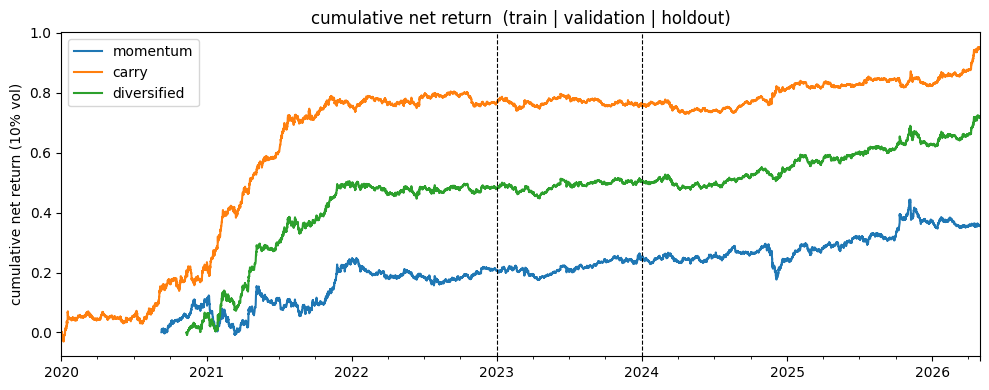

In [15]:
# each sleeve stumbles in a different regime; the blend stays steady (holdout = last segment)
vt = lambda r: r * (0.10 / ANN) / r.loc[TRAIN[0]:TRAIN[1]].std()   # 10% vol, for a fair comparison
ax = pd.DataFrame({'momentum': vt(mom), 'carry': vt(carry), 'diversified': vt(combo)}
                  ).loc[TRAIN[0]:].cumsum().plot(figsize=(10, 4),
                  title='cumulative net return  (train | validation | holdout)')
for b in (VALID[0], HOLDOUT[0]):
    ax.axvline(pd.Timestamp(b), color='k', ls='--', lw=.8)
ax.set_ylabel('cumulative net return (10% vol)'); plt.tight_layout(); plt.show()

Momentum alone is positive but weak, and carry alone is strong yet negative in 2023. The blend is net-positive in every period, including the holdout, because the two are about uncorrelated and strong in different regimes: momentum carried 2023, carry carried 2024-26. Re-estimating the weights each quarter on past data, instead of fitting them to the test window, is what lets that diversification show up out-of-sample rather than only in-sample.

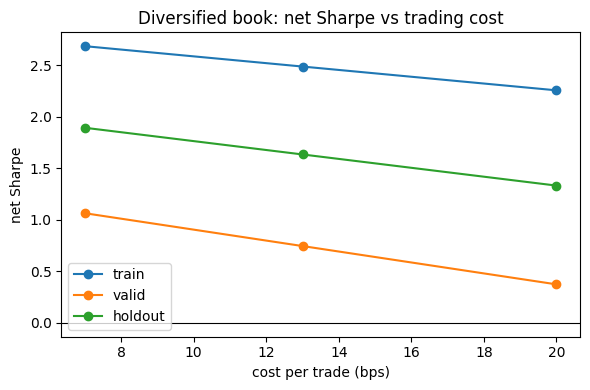

In [16]:
# the book stays net-positive across cost assumptions, in every period
costs = [7, 13, 20]
books = {b: book(b) for b in costs}
res = pd.DataFrame({p: [SR(books[b], w) for b in costs]
                    for p, w in [('train', TRAIN), ('valid', VALID), ('holdout', HOLDOUT)]}, index=costs)
res.plot(marker='o', figsize=(6, 4), title='Diversified book: net Sharpe vs trading cost')
plt.axhline(0, color='k', lw=.8); plt.xlabel('cost per trade (bps)'); plt.ylabel('net Sharpe')
plt.tight_layout(); plt.show()

### Performance

Return, volatility, Sharpe, max drawdown, alpha, alpha t-stat, and beta vs BTC. The alpha t-stat (intercept of a regression on BTC) shows whether the excess return is real; above about 2 is meaningful alongside a near-zero beta. Scaled to 10% annual volatility.

In [17]:
# return, vol, Sharpe, max drawdown, alpha, alpha t-stat, beta (vs BTC); scaled to 10% annual vol
btc = ret['BTC']
def perf(r, target=0.10):
    r = r.dropna()
    r = r * (target / ANN) / r.loc[TRAIN[0]:TRAIN[1]].std()       # scale to 10%/yr vol
    m = btc.reindex(r.index); n = len(r)
    X = np.column_stack([np.ones(n), m.values])                  # regress on [1, BTC]
    b = np.linalg.lstsq(X, r.values, rcond=None)[0]
    resid = r.values - X @ b
    se = np.sqrt(np.diag((resid @ resid) / (n - 2) * np.linalg.inv(X.T @ X)))
    cum = r.cumsum()
    return {'ann_return': r.mean()*365*6, 'ann_vol': r.std()*ANN, 'sharpe': r.mean()/r.std()*ANN,
            'max_drawdown': (cum - cum.cummax()).min(), 'alpha': b[0]*365*6,
            'alpha_tstat': b[0]/se[0], 'beta': b[1]}

summary = pd.DataFrame({'momentum': perf(mom), 'carry': perf(carry), 'diversified': perf(combo)}).T
print('Full-sample performance at 20 bps (vol-targeted 10%/yr, benchmark = BTC):')
print(summary.round(2).to_string())

Full-sample performance at 20 bps (vol-targeted 10%/yr, benchmark = BTC):
             ann_return  ann_vol  sharpe  max_drawdown  alpha  alpha_tstat  beta
momentum           0.06     0.09    0.74         -0.13   0.06         1.77 -0.00
carry              0.15     0.08    1.85         -0.07   0.15         4.74 -0.01
diversified        0.13     0.08    1.62         -0.07   0.13         3.86 -0.01


### Caveats

The holdout is not a clean one-shot test: it was evaluated three times as the approach evolved, first on a hand-built strategy (no literature, no rebalancing), then with the literature trend signal, and finally with that signal plus quarterly rebalancing (this book). Each look erodes its independence, so treat the result as robust and reasoned rather than proven; a genuinely clean test needs future data. The 35-coin universe is fixed, with no point-in-time membership, so there is mild survivorship bias. The 7 bps cost is optimistic for limit orders, which is why we also report 13 and 20 bps. And the carry sleeve caps funding at 0.5% per 8h to avoid one-off spikes like FTX/SOL.

### Conclusion

No single fast signal beats costs. A diversified, slow, quarterly-rebalanced book of momentum and carry is net-positive across train, validation, and holdout at every cost level, with near-zero BTC beta and a significant alpha t-stat. The edge is breadth, diversification, low turnover, and honest testing.